# **Practical 1- Write a Simple Python program to simulate perceptron using NumPy**

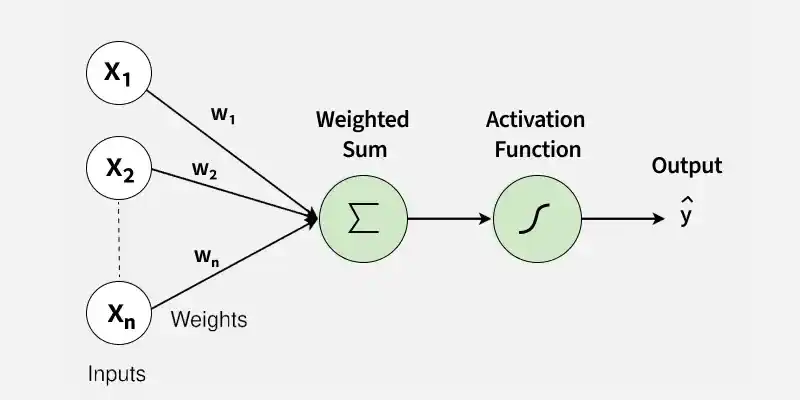

In [ ]:
# 1. Simulate a Perceptron using NumPy
import numpy as np
# we are importing NumPy which is a scientific library
# used for matrix multiplication as it introduces ndarray which is
# a high performing data structure essentially used to store and
# manipulate datsets in extremely high speed.
# Unlike standard Python lists which store pointers
# to scattered objects in memory, NumPy arrays store data
# in contiguous memory blocks.

we are defining the activation function here for binary classification of the outputs we will be getting.
here in this code we are defining step_function  which takes in the varibale x
as a parameter and checks if x>=0 it returns 1 else 0

In [ ]:

# Step activation function
def step_function(x):
    return 1 if x >= 0 else 0
# we are defining the activation function here for binary classification of the outputs
# we will be getting.
# here in this code we are defining step_function  which takes in the varibale x
# as a parameter and checks if x>=0 it returns 1 else 0



In [ ]:
# Perceptron class
class Perceptron: #we are defining the perceptron class here
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.zeros(input_size)
        self.bias = 0
        self.lr = learning_rate



    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return step_function(z)




    def train(self, X, y, epochs=10):
        for epoch in range(epochs):
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                error = target - prediction
                self.weights += self.lr * error * xi
                self.bias += self.lr * error

```
import numpy as np

class Perceptron: # we are defining the perceptron class here
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.zeros(input_size)
        self.bias = 0
        self.lr = learning_rate
```


* **`class Perceptron`**: A class is a blueprint for creating objects. It bundles the state of the neuron (its weights and bias) together with the actions it can perform (like predicting and training).
* **`def __init__(self, ...)`**: This is the constructor method. It runs automatically when a new object is created. The `self` parameter is how the object refers to its own specific instance in memory.
* **`self.weights = np.zeros(input_size)`**:
  * **`np.zeros`**: A NumPy function that creates an array filled with `0.0`. For example, if `input_size` is 2 (e.g., for an AND gate with two inputs), it creates `array([0., 0.])`.
  * **Why zeros?** We initialize the "importance multipliers" (weights) to zero before the neuron starts learning from data.
* **`self.bias = 0`**: The bias is a baseline threshold modifier. It allows the neuron to shift its decision boundary even if all input values are zero.
* **`self.lr = learning_rate`**: A hyperparameter (default `0.1`) controlling how drastically the neuron adjusts its weights when it makes a mistake. Too high causes erratic learning; too low makes learning extremely slow.


```
def predict(self, x):
    z = np.dot(x, self.weights) + self.bias
    return step_function(z)
```

### What it does
Takes a single input data point `x` (e.g., `[1, 0]`) and predicts the output.

### `np.dot(x, self.weights)`
Calculates the **dot product** between the input values and their corresponding weights.

Mathematically:

$$
(x_1 \times w_1) + (x_2 \times w_2)
$$

**Example:**

If:

$$
x = [1, 0]
$$

and

$$
\text{weights} = [0.2, 0.3]
$$

then:

$$
(1 \times 0.2) + (0 \times 0.3) = 0.2
$$

####`+ self.bias`
Adds the baseline **bias** to the dot product.

The result, `z`, represents the total weighted input (or "electrical charge") entering the neuron.

### `return step_function(z)`
Passes `z` through the **activation function**.

The step function determines whether the neuron:

- Outputs `1` (fires/activates), or
- Outputs `0` (does not fire).

```
def train(self, X, y, epochs=10):
    for epoch in range(epochs):
        for xi, target in zip(X, y):
            prediction = self.predict(xi)
            error = target - prediction
            self.weights += self.lr * error * xi
            self.bias += self.lr * error
```

### What it does
Trains the perceptron by repeatedly making predictions, measuring errors, and adjusting the weights and bias to improve future predictions.

### `epochs=10`
An **epoch** is one complete pass through the entire training dataset.

The outer loop runs **10 times**, giving the perceptron multiple opportunities to learn from the data.

### `zip(X, y)`
Pairs each input sample (`X`) with its corresponding target label (`y`).

For example:

```
X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [0, 0, 0, 1]
```

`zip(X, y)` produces:

```
([0, 0], 0)
([0, 1], 0)
([1, 0], 0)
([1, 1], 1)
```

### `prediction = self.predict(xi)`
The perceptron makes a prediction using its current weights and bias.

### `error = target - prediction`
Calculates how far the prediction is from the correct answer.

Possible values:

- `0` → Correct guess
- `1` → Guessed `0`, needed `1`
- `-1` → Guessed `1`, needed `0`

### `self.weights += self.lr * error * xi`
Updates the weights using the **Perceptron Learning Rule**.

#### If `error == 0`
No update is made because the prediction was correct.

#### If `error == 1`
A fraction of the input is added to the weights, making future predictions more likely to be higher.

#### If `error == -1`
A fraction of the input is subtracted from the weights, making future predictions more likely to be lower.

Mathematically:

$$
w_{new} = w_{old} + \eta \cdot error \cdot x
$$

where:

- $w$ = weight
- $\eta$ = learning rate (`self.lr`)
- $error$ = prediction error
- $x$ = input feature

### `self.bias += self.lr * error`
Updates the bias using the same learning rule.

#### If `error == 0`
No change.

#### If `error == 1`
Bias increases.

#### If `error == -1`
Bias decreases.

Mathematically:

$$
b_{new} = b_{old} + \eta \cdot error
$$

The bias adjustment shifts the neuron's activation threshold, helping the perceptron learn a better decision boundary.

In [ ]:
# Training data for AND gate
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])


Defines the input matrix X and target array y for an AND gate (outputs 1 only when both inputs are 1).



In [ ]:
# Train the perceptron
p = Perceptron(input_size=2)
p.train(X, y, epochs=10)

p = Perceptron(input_size=2): Instantiates the object. Python allocates memory, runs the constructor, and assigns the object to p.

p.train(X, y, epochs=10): Calls the train method on the object p, executing the learning loop to adjust weights and bias.

In [ ]:
# Test predictions
print("Predictions:")
for xi in X:
    print(f"Input: {xi}, Output: {p.predict(xi)}")

Predictions:
Input: [0 0], Output: 0
Input: [0 1], Output: 0
Input: [1 0], Output: 0
Input: [1 1], Output: 1


### Testing the Trained Perceptron

After training, the perceptron loops through all input samples and uses:

```
predict(xi)
```

to generate predictions using the **updated weights and bias** learned during training.

This step evaluates whether the perceptron has successfully learned the desired pattern from the training data.

### Output

```text
Predictions:
Input: [0 0], Output: 0
Input: [0 1], Output: 0
Input: [1 0], Output: 0
Input: [1 1], Output: 1
```

### Interpretation

The perceptron correctly classifies all four input combinations:

| Input | Expected Output | Predicted Output |
|---------|----------------|------------------|
| `[0, 0]` | 0 | 0 |
| `[0, 1]` | 0 | 0 |
| `[1, 0]` | 0 | 0 |
| `[1, 1]` | 1 | 1 |

This matches the truth table of the **AND logic gate**, meaning the perceptron has successfully learned the AND operation.

The learned decision rule can be summarized as:

- Output **1** only when **both inputs are 1**.
- Output **0** for all other input combinations.